# Know your customers

One of the most common applications of KMeans is to get to know your customers. Take a very simple dataset that is Mall Customers to try to discover customer segmentations.

0. Import usuals librairies

In [50]:
import os
os.environ["OMP_NUM_THREADS"] = "1"


In [51]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
# Import plotly
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
# setting Jedha color palette as default
pio.templates["jedha"] = go.layout.Template(
    layout_colorway=["#4B9AC7", "#4BE8E0", "#9DD4F3", "#97FBF6", "#2A7FAF", "#23B1AB", "#0E3449", "#015955"]
)
pio.templates.default = "jedha"
pio.renderers.default = "svg" # to be replaced by "iframe" if working on JULIE

1. Import the ```Mall_Customers.csv``` dataset

In [52]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [53]:
print("Nombres de lignes : ", len(df))
print()
print("Apercu du dataset : ")
print(df.head())
print()
print("Statistiques basiques :")
print(df.describe(include='all'))
print()
print(df.isnull().sum() * 100 / len(df))

Nombres de lignes :  200

Apercu du dataset : 
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Statistiques basiques :
        CustomerID   Genre         Age  Annual Income (k$)  \
count   200.000000     200  200.000000          200.000000   
unique         NaN       2         NaN                 NaN   
top            NaN  Female         NaN                 NaN   
freq           NaN     112         NaN                 NaN   
mean    100.500000     NaN   38.850000           60.560000   
std      57.879185     NaN   13.969007           26.264721   
min       1.000000     NaN   18.000000           15.000000   
25%   

2. Remove the "CustomerID" variable from your dataset. 

In [54]:
col_drop = ["CustomerID"]
print("Les colonnes suivantes vont être jetées : ", col_drop)
df = df.drop(col_drop, axis=1)
print("...Terminé.")
df.head()

Les colonnes suivantes vont être jetées :  ['CustomerID']
...Terminé.


,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


3. Make all the preprocessings

In [55]:
numerical_features = df.columns[1:]
categorical_features = df.columns[:1]
print("preprocessing sur le train set...")
print(df.head())
numeric_transformers = Pipeline(steps=[
    ("scaler", StandardScaler())
])
categorical_transformers = Pipeline(steps=[
    ("encoder", OneHotEncoder(drop="first"))
])
preprocessor = ColumnTransformer([
    ("num", numeric_transformers, numerical_features),
    ("cat", categorical_transformers, categorical_features)
])

X = preprocessor.fit_transform(df)
print("...Terminé.")
X[:5]

preprocessing sur le train set...
    Genre  Age  Annual Income (k$)  Spending Score (1-100)
0    Male   19                  15                      39
1    Male   21                  15                      81
2  Female   20                  16                       6
3  Female   23                  16                      77
4  Female   31                  17                      40
...Terminé.


array([[-1.42456879, -1.73899919, -0.43480148,  1.        ],
       [-1.28103541, -1.73899919,  1.19570407,  1.        ],
       [-1.3528021 , -1.70082976, -1.71591298,  0.        ],
       [-1.13750203, -1.70082976,  1.04041783,  0.        ],
       [-0.56336851, -1.66266033, -0.39597992,  0.        ]])

4. We are going to build our clusters, but to do so, we need to know the optimum number of clusters we need. First use the ```Elbow``` method to see if we can see how many we need to take as a value for ```k```.

In [57]:
wcss = []
k = []
for i in range(1,15):
    Kmeans = KMeans(n_clusters=i, random_state=0)
    Kmeans.fit(X)
    wcss.append(Kmeans.inertia_)
    k.append(i)
wcss

c:\Users\briic\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

c:\Users\briic\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

c:\Users\briic\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

c:\Users\briic\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than 

[649.28,
 438.52241155677746,
 346.0375547714672,
 254.36171423484498,
 227.01672798042068,
 194.00424193610988,
 183.0284960819348,
 151.03482636968906,
 145.7922195039509,
 141.23944897726113,
 131.22474565700696,
 116.45798452998244,
 112.54458292997518,
 103.3983947255772]

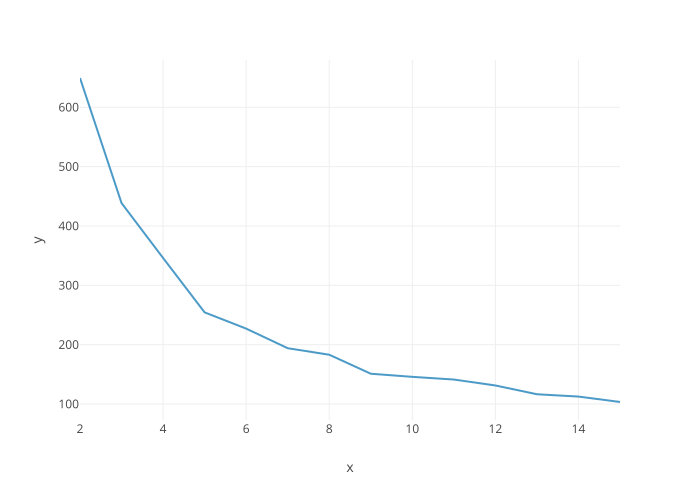

In [69]:
fig = px.line(x = range(2,16), y = wcss)
fig.show()

5. Then use the _Silhouette_ method to see if we can refine our hypothesis for ```k```.

In [60]:
sil = []
k = []

for i in range(2, 15):
    Kmeans = KMeans(n_clusters=i, random_state=0, n_init='auto')
    Kmeans.fit(X)
    sil_score = float(silhouette_score(X, Kmeans.predict(X)))
    sil.append(sil_score)
    k.append(i)

sil

c:\Users\briic\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

c:\Users\briic\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

c:\Users\briic\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

c:\Users\briic\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than 

[0.3031976564160757,
 0.3120911967450968,
 0.35044061449694197,
 0.3101586031776234,
 0.3148516280991192,
 0.28810794551986924,
 0.33200051039371054,
 0.3019901116126307,
 0.30015660334449235,
 0.31755144809441693,
 0.33161681893933886,
 0.33330591936797177,
 0.3276840941369214]

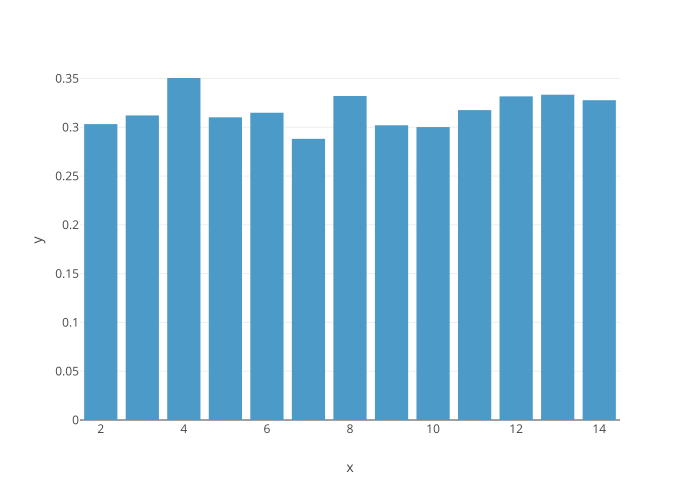

In [70]:
# Affichage de scores en fonction du nombre de clusters
fig = px.bar(x = range(2,15), y = sil)
fig.show()


6. Next, we will take $K=6$ clusters. Apply the KMeans to your dataset.

In [61]:
Kmeans = KMeans(n_clusters=6, random_state=0)

Kmeans.fit(X)

c:\Users\briic\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



KMeans(n_clusters=6, random_state=0)

In [62]:
df["Cluster_Kmeans"] = Kmeans.labels_
df.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster_Kmeans
0,Male,19,15,39,5
1,Male,21,15,81,5
2,Female,20,16,6,1
3,Female,23,16,77,5
4,Female,31,17,40,5


7. Let's create a graph that will allow us to visualize each of the clusters. We will first take the ```Spending Score``` as the ordinate and the ```Annual Income``` as the abscissa. 

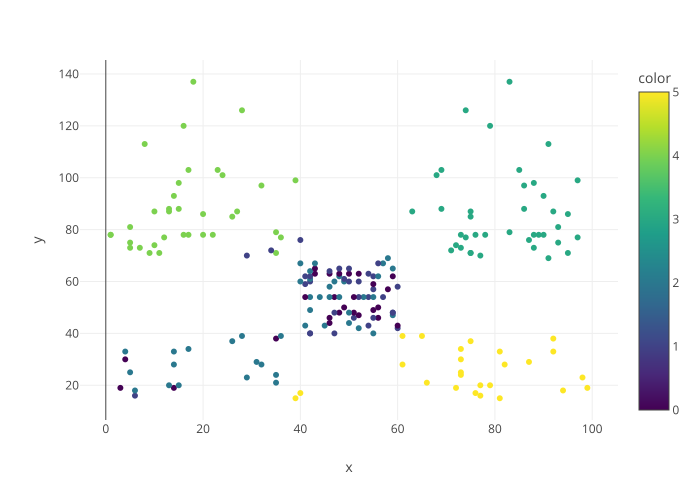

In [63]:
fig = px.scatter(x=df["Spending Score (1-100)"], y=df["Annual Income (k$)"], color=df["Cluster_Kmeans"])
fig.show()

8. We have a nice visualization with a nice cluster separation. Look this time at the variable ```Age``` in relation to the ```Spending Score```. What do you notice?

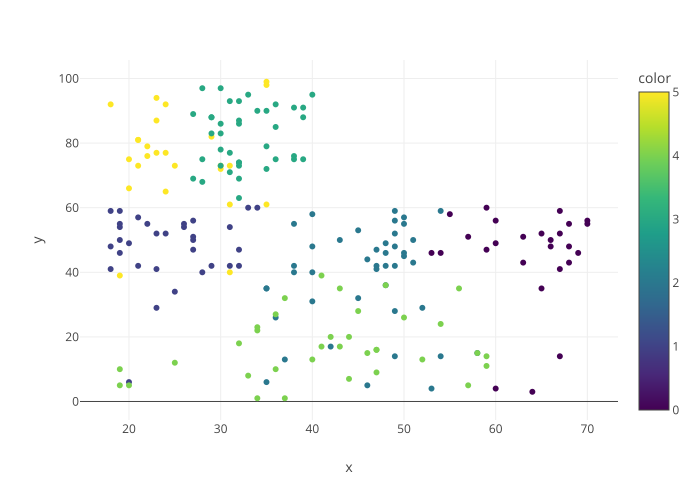

In [64]:
fig2 = px.scatter(x=df["Age"], y=df["Spending Score (1-100)"], color=df["Cluster_Kmeans"])
fig2.show()

----> This time clusters are definitely less visible. 

9. Finally, make a 3d scatter plot of your clusters by using all the quantitative features

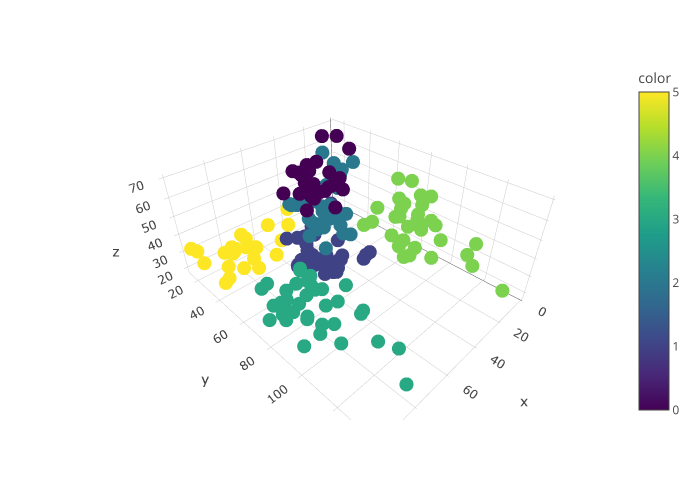

In [65]:
fig3 = px.scatter_3d(x=df["Spending Score (1-100)"], y=df["Annual Income (k$)"], z=df["Age"], color=df["Cluster_Kmeans"])
fig3.show()